In [25]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

In [6]:
engine = create_engine('sqlite:////Users/apple/Documents/Python/datasets/data.db')

In [7]:
weather = pd.read_sql('weather', engine)

In [8]:
weather.head()

,station,name,latitude,longitude,elevation,date,month,awnd,prcp,snow,tavg,tmax,tmin
0,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,42.7,12/01/2017,December,5.37,0.00,0.0,,52,42
1,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,42.7,12/02/2017,December,3.13,0.00,0.0,,48,39
2,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,42.7,12/03/2017,December,2.01,0.00,0.0,,48,42
3,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,42.7,12/04/2017,December,3.58,0.00,0.0,,51,40
4,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,42.7,12/05/2017,December,6.71,0.75,0.0,,61,50


In [9]:
weather1 = pd.read_sql('SELECT * FROM weather', engine)

In [10]:
weather1.head()

,station,name,latitude,longitude,elevation,date,month,awnd,prcp,snow,tavg,tmax,tmin
0,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,42.7,12/01/2017,December,5.37,0.00,0.0,,52,42
1,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,42.7,12/02/2017,December,3.13,0.00,0.0,,48,39
2,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,42.7,12/03/2017,December,2.01,0.00,0.0,,48,42
3,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,42.7,12/04/2017,December,3.58,0.00,0.0,,51,40
4,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,42.7,12/05/2017,December,6.71,0.75,0.0,,61,50


In [21]:
weather_50 = weather['tmax'] > 50
weather[weather_50].count()

station      31
name         31
latitude     31
longitude    31
elevation    31
date         31
month        31
awnd         31
prcp         31
snow         31
tavg         31
tmax         31
tmin         31
dtype: int64

# Refining the Import (selecting columns)

Selecting columns -- cvs & excel : usecols
Modify this using sql: 

In [20]:
Query = """select station,name,month,date 
from weather where tmax > 50"""

w_50 = pd.read_sql(Query, engine)
w_50.shape

(31, 4)

In [22]:
# Create query to get hpd311calls records about safety
query = """
select *
from hpd311calls
where  complaint_type = 'SAFETY';
"""

# Query the database and assign result to safety_calls
safety_calls = pd.read_sql(query, engine)

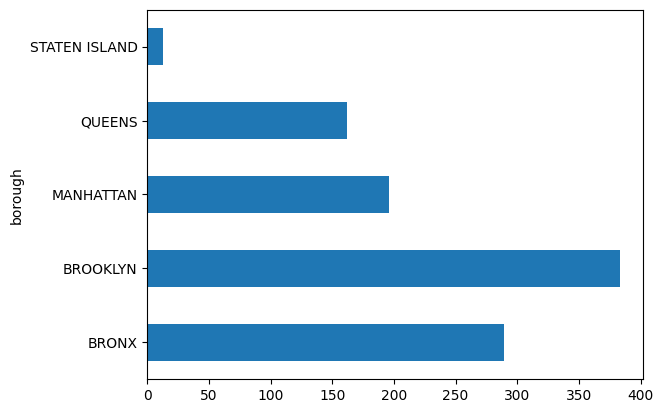

In [26]:
# Graph the number of safety calls by borough
call_counts = safety_calls.groupby('borough').unique_key.count()
call_counts.plot.barh()
plt.show()

In [27]:
call_counts

borough
BRONX            289
BROOKLYN         383
MANHATTAN        196
QUEENS           162
STATEN ISLAND     13
Name: unique_key, dtype: int64

# Streamlime data ingestion with sql 

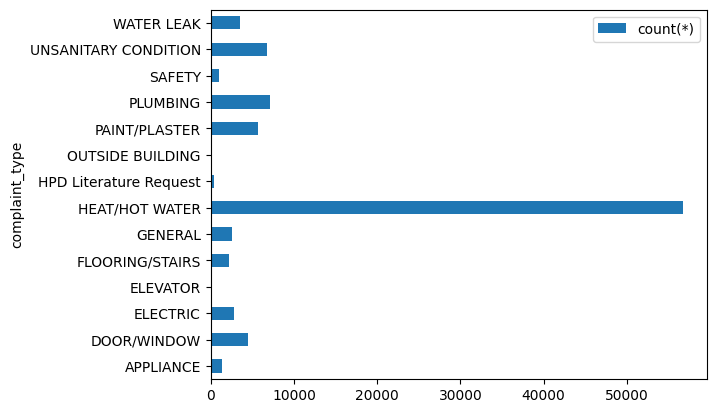

In [29]:
# more complex filtering
query = """
select complaint_type, 
     count(*)
  FROM hpd311calls
  group by  complaint_type;
"""

# Create dataframe of call counts by issue
calls_by_issue = pd.read_sql(query, engine)

# Graph the number of calls for each housing issue
calls_by_issue.plot.barh(x="complaint_type")
plt.show()

In [30]:
# Create a query to get month and max tmax by month
query = """
SELECT month, 
       max(tmax)
  FROM weather 
  group by month;"""

# Get dataframe of monthly weather stats
weather_by_month = pd.read_sql(query, engine)

# View weather stats by month
print(weather_by_month)

      month  max(tmax)
0  December         61
1  February         78
2   January         61
3     March         62


In [44]:
# Create a query to get month, max tmax, and min tmin by month
query = """
SELECT month, 
	   MAX(tmax) as Max, 
        Min(tmax) as Min
  FROM weather 
 GROUP BY month;
"""

# Get dataframe of monthly weather stats
weather_by_month = pd.read_sql(query, engine)

# View weather stats by month
weather_by_month = weather_by_month.sort_values('month')

In [52]:
weather_by_month.set_index('month',inplace = True)

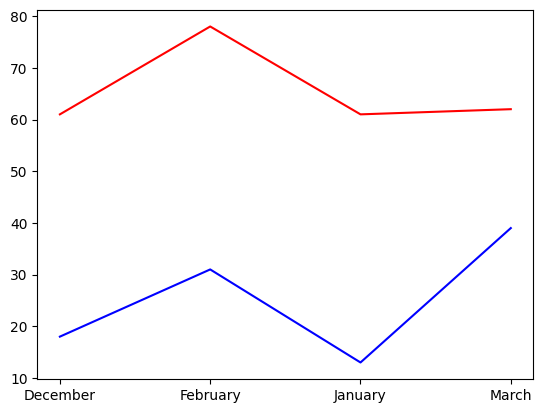

In [55]:
plt.plot(weather_by_month.index,weather_by_month.Max, color = 'red')
plt.plot(weather_by_month.index, weather_by_month.Min, color = 'blue')
plt.xlabel=('Month')
plt.ylabel=('Temparature')
plt.show()

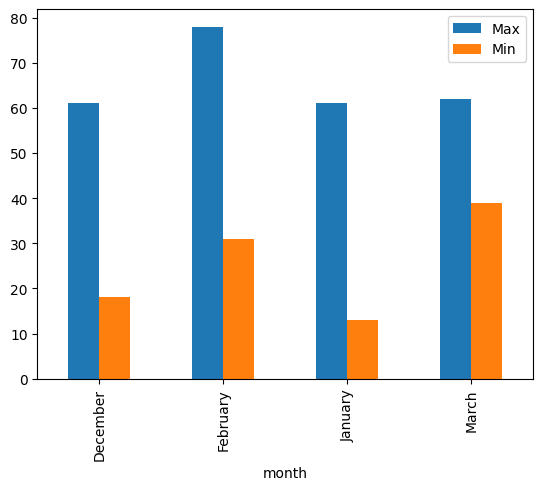

In [54]:
weather_by_month.plot(kind='bar')
plt.xlabel=('Month')
plt.ylabel=('Temparature')
plt.show()

# More Complex queries: Joins 

In [56]:
# Query to join weather to call records by date columns
query = """
SELECT * 
  FROM hpd311calls
  JOIN weather 
  ON hpd311calls.created_date = weather.date;
"""

# Create dataframe of joined tables
calls_with_weather = pd.read_sql(query, engine)

# View the dataframe to make sure all columns were joined
calls_with_weather.head()

,unique_key,created_date,agency,complaint_type,incident_zip,incident_address,community_board,borough,station,name,...,longitude,elevation,date,month,awnd,prcp,snow,tavg,tmax,tmin
0,38070822,01/01/2018,HPD,HEAT/HOT WATER,10468,2786 JEROME AVENUE,07 BRONX,BRONX,USW00094728,"NY CITY CENTRAL PARK, NY US",...,-73.96925,42.7,01/01/2018,January,7.83,0.0,0.0,,19,7
1,38065299,01/01/2018,HPD,PLUMBING,10003,323 EAST 12 STREET,03 MANHATTAN,MANHATTAN,USW00094728,"NY CITY CENTRAL PARK, NY US",...,-73.96925,42.7,01/01/2018,January,7.83,0.0,0.0,,19,7
2,38066653,01/01/2018,HPD,HEAT/HOT WATER,10452,1235 GRAND CONCOURSE,04 BRONX,BRONX,USW00094728,"NY CITY CENTRAL PARK, NY US",...,-73.96925,42.7,01/01/2018,January,7.83,0.0,0.0,,19,7
3,38070264,01/01/2018,HPD,HEAT/HOT WATER,10032,656 WEST 171 STREET,12 MANHATTAN,MANHATTAN,USW00094728,"NY CITY CENTRAL PARK, NY US",...,-73.96925,42.7,01/01/2018,January,7.83,0.0,0.0,,19,7
4,38072466,01/01/2018,HPD,HEAT/HOT WATER,11213,1030 PARK PLACE,08 BROOKLYN,BROOKLYN,USW00094728,"NY CITY CENTRAL PARK, NY US",...,-73.96925,42.7,01/01/2018,January,7.83,0.0,0.0,,19,7


In [57]:
# Modify query to join tmax and tmin from weather by date
query = """
SELECT hpd311calls.created_date, 
	   COUNT(*), 
       weather.tmax,
       weather.tmin
  FROM hpd311calls 
       join weather on 
        hpd311calls.created_date = date
 WHERE hpd311calls.complaint_type = 'HEAT/HOT WATER' 
 GROUP BY hpd311calls.created_date;
 """

# Query database and save results as df
df = pd.read_sql(query, engine)

# View first 5 records
print(df.head())

  created_date  COUNT(*)  tmax  tmin
0   01/01/2018      4597    19     7
1   01/02/2018      4362    26    13
2   01/03/2018      3045    30    16
3   01/04/2018      3374    29    19
4   01/05/2018      4333    19     9
